# GoalLab Stage 02: Estimate the value of inspecting evidence

Created by Shivam Bharadwaj · [Course home](../../../README.md) · [Stage map](../STAGES.md)

[Stage 01](01_mdp_dynamic_programming.ipynb) · [Stage 03](03_q_learning.ipynb)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/apply-theory/02_mc_vs_td.ipynb)

**Build:** estimate how useful evidence states are under a fixed random investigation policy. This stage predicts value; it does not optimize the policy.

**Run:** use the full repository, install `requirements.txt` (Stage 09 also uses `requirements-modern.txt`), then restart the kernel and run all cells. Every stage reconstructs its inputs from shared GoalLab modules; earlier notebook execution is not required. The project progression is cumulative in capabilities, without hidden notebook state.

Code: MIT. Text and plots: CC BY 4.0. Results below are reproduced from the supplied GoalLab cases; the evaluation section explains their scope and failure cases.

**Learn the algorithm first:** [Course Notebook 02](../../../notebooks/02_mc_vs_td.ipynb). Then use this GoalLab stage to apply it to evidence gathering and briefing verification.


In [1]:
import sys, subprocess, platform, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'rl_course').is_dir()), Path.cwd())
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course' / 'goallab.py').exists():
    raise FileNotFoundError('Use the complete repository revision containing the GoalLab stages.')
sys.path.insert(0, str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course import goallab as goal
from rl_course import goallab_learning as learning
torch.set_num_threads(2)
%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#af824a', '#768165', '#87708c', '#f5f1e8'
plt.rcParams.update({'figure.figsize': (9, 4), 'figure.dpi': 110, 'figure.facecolor': PAPER,
    'axes.facecolor': PAPER, 'text.color': INK, 'axes.labelcolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(str(x).replace('|', '&#124;').replace('\n', '<br>') for x in row) + ' |' for row in rows)))
def learning_plot(runs):
    for label, run in runs.items():
        h = run['history']
        plt.plot(h[:, 0], h[:, 1], label=label)
    plt.xlabel('Training environment actions'); plt.ylabel('Exact policy return')
    plt.legend(); plt.tight_layout(); plt.show()
def report_policies(runs):
    table(['Controller', 'Exact return', 'Held-out briefing success', 'Calls/case'],
          [[label, round(run['env'].values(run['policy'])[0][run['env'].start_index], 3),
            f"{learning.heldout(run['policy'])['success']:.1%}", learning.heldout(run['policy'])['calls']]
           for label, run in runs.items()])
workspace = goal.make_workspace(7, 'test')
print(f'{goal.VERSION} | Python {platform.python_version()} | NumPy {np.__version__} | Torch {torch.__version__} | CPU')

GoalLab-v1 | Python 3.12.4 | NumPy 1.26.4 | Torch 2.11.0+cu130 | CPU


## Shared contract

One source is an approved measurement for the requested period. Other sources are drafts or forecasts, deliberately newer and numerically different. Training rows use 0..3; held-out rows use 4..7 and a different period. Authority rules stay the same. `search` reveals IDs and timestamps; `read` reveals content. A valid briefing needs the correct value, period, and citation.

The simulator and models are readable teaching code, not a security boundary. Final `verify()` is outside the policy interface. The first eight stages use a finite two-source abstraction: read twice, choose a citation, then submit or claim completion. Claiming completion produces no briefing. This fixed horizon makes exact comparisons possible; later stages vary investigation budgets.

## Learning objectives and the stage contract

Separate prediction from control; compute an MC return and a TD target; interpret per-state estimation error.

**Input:** the shared evidence workspace or the preceding component reconstructed below. **Output:** the capability named in this stage, evaluated against the common briefing contract. Read the worked calculation before running the full experiment; then inspect the implementation and predict the constraint exercise.

## Work it out: an investigation is a sequence of rewards

A successful four-action investigation has rewards `[-0.02, -0.02, -0.02, 0.98]`. Its returns-to-go differ by state. MC uses those realized returns. TD uses the next state's current value estimate, so its target can be wrong early in training even when the episode eventually succeeds.

Predict the first state's update if its current estimate is zero and the next-state estimate is 0.5. Which method waits for the final submission?

In [2]:
rewards=np.array([-.02,-.02,-.02,.98])
returns=np.cumsum(rewards[::-1])[::-1]
td_target=rewards[0]+.5
table(['Decision','Observed reward','MC return'],[[i+1,r,g] for i,(r,g) in enumerate(zip(rewards,returns))])
print('First-state TD target:',td_target,'; terminal target:',rewards[-1])
assert np.isclose(returns[0],.92) and np.isclose(td_target,.48)

| Decision | Observed reward | MC return |
|---|---|---|
| 1 | -0.02 | 0.9199999999999999 |
| 2 | -0.02 | 0.94 |
| 3 | -0.02 | 0.96 |
| 4 | 0.98 | 0.98 |

First-state TD target: 0.48 ; terminal target: 0.98


## Build the component

The central implementation is included here so you can step through and edit the update or tool logic. The shared modules retain the same reference implementation for the integrated project. Inspect shapes, terminal handling, frozen quantities, and the evaluator boundary before training.

In [3]:
from collections import deque
from copy import deepcopy
from torch import nn
from torch.distributions import Categorical
EvidenceMDP = goal.EvidenceMDP
greedy = learning.greedy
network = learning.network
def prediction(seed=7, episodes=600):
    env = EvidenceMDP()
    rng = np.random.default_rng(seed)
    policy = np.full((env.n, 2), .5)
    truth, _ = env.values(policy)
    mc, td, counts = np.zeros(env.n), np.zeros(env.n), np.zeros(env.n)
    history = []
    visited = np.zeros(env.n, dtype=bool)
    for ep in range(episodes):
        state = env.start_index
        trajectory = []
        for _ in range(4):
            action = int(rng.integers(2))
            ns, reward, done = env.step(state, action, rng)
            trajectory.append((state, reward, ns, done))
            visited[state] = True
            state = ns
        total = 0.
        for s, r, ns, done in reversed(trajectory):
            total = r + total
            counts[s] += 1
            mc[s] += (total - mc[s]) / counts[s]
        for s, r, ns, done in trajectory:
            td[s] += .1 * (r + (0 if done else td[ns]) - td[s])
        if (ep + 1) % 24 == 0:
            # All decision states in this enumerated MDP are reachable under the random policy.
            idx = [i for i in range(env.n) if i != env.end_index]
            history.append(((ep + 1) * 4, np.sqrt(np.mean((mc[idx]-truth[idx])**2)),
                            np.sqrt(np.mean((td[idx]-truth[idx])**2))))
    return {'env': env, 'mc': mc, 'td': td, 'truth': truth, 'history': np.array(history)}

## 1. MC and TD on identical trajectories

Monte Carlo waits for the whole briefing attempt and averages its return. TD updates after each tool decision using the next state's current estimate. It is the difference between grading a whole investigation and revising a forecast as evidence arrives. Time-indexed states cannot repeat, so first-visit and every-visit MC coincide here.

MC update: `V += (return - V) / visits`. TD update: `V += 0.1 * (reward + V_next - V)`, with zero continuation at termination. RMSE includes every reachable decision state with equal weight, not only the starting state.

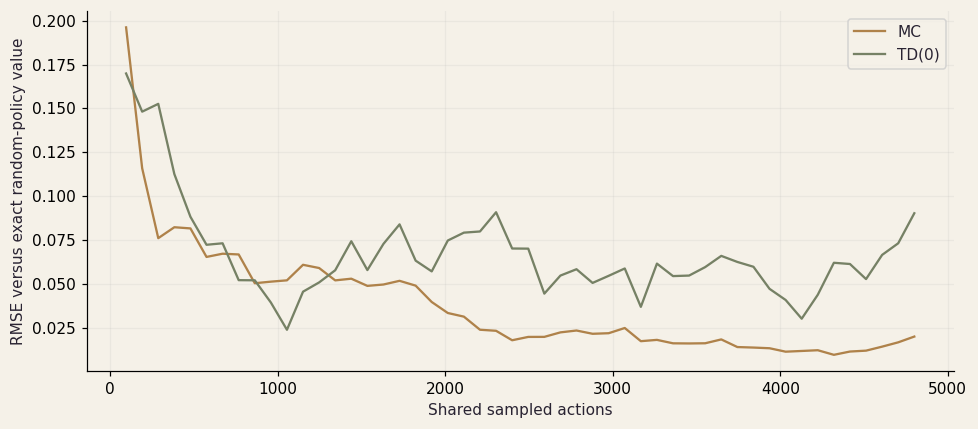

| Exact start value | MC estimate | TD estimate |
|---|---|---|
| 0.10750000000000001 | 0.09999999999999988 | 0.07721566841513726 |

In [4]:
run = prediction(7, episodes=1200)
h = run['history']
plt.plot(h[:,0],h[:,1],label='MC'); plt.plot(h[:,0],h[:,2],label='TD(0)')
plt.xlabel('Shared sampled actions'); plt.ylabel('RMSE versus exact random-policy value'); plt.legend(); plt.tight_layout(); plt.show()
s = run['env'].start_index
table(['Exact start value','MC estimate','TD estimate'], [[run['truth'][s],run['mc'][s],run['td'][s]]])

## 2. Terminal values and seed sensitivity

The final submission contributes its reward once. Bootstrapping from a terminal value would invent future evidence. Constant-step TD can fluctuate even after many samples; do not declare a universal winner from one curve.

In [5]:
runs = [prediction(seed,1200) for seed in (7,19,31)]
table(['Seed','Final MC RMSE','Final TD RMSE'], [[seed,*r['history'][-1,1:]] for seed,r in zip((7,19,31),runs)])
assert all(r['mc'][r['env'].end_index] == r['td'][r['env'].end_index] == 0 for r in runs)

| Seed | Final MC RMSE | Final TD RMSE |
|---|---|---|
| 7 | 0.020112956271656168 | 0.09034532933943 |
| 19 | 0.023852576128192846 | 0.06028593879884418 |
| 31 | 0.03641172934145745 | 0.05368021304530062 |

## Interpret the evidence

MC and TD curves may cross. A constant TD step size keeps adapting, while sample-average MC decays its effective step size. Before attributing a difference to bootstrapping, identify which hyperparameters also differ.

## Change a constraint: predict first

Reduce training to 120 episodes. Predict which estimates become less dependable, and explain why one observed ordering does not establish a general MC-versus-TD result.

### Worked solution

Run this after writing your prediction. Compare the changed condition with the reference condition above.

In [6]:
small = prediction(7,120)
table(['Episodes','MC RMSE','TD RMSE'], [[120,*small['history'][-1,1:]],[1200,*run['history'][-1,1:]]])

| Episodes | MC RMSE | TD RMSE |
|---|---|---|
| 120 | 0.08170463963923344 | 0.08832101350650347 |
| 1200 | 0.020112956271656168 | 0.09034532933943 |

## What this stage contributes

A value-estimation experiment for GoalLab evidence states. Next, improve decisions instead of merely predicting them. Theory: [Monte Carlo](../../../chapters/17-monte-carlo-methods/README.md), [TD](../../../chapters/18-temporal-difference-learning/README.md).

[Stage 01](01_mdp_dynamic_programming.ipynb) · [Stage 03](03_q_learning.ipynb)